<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Table of Contents:

- [Imports](#imports)
- [Architectural and Performance Decisions](#architectual-and-performance-decisions)
- [Complex Network Feature Engineering](#complex-network-feature-engineering)
- [Initial Data Dictionary](#initial-data-dictionary)
- [Statistical and Associative Data Exploration](#statistical-and-associative-data-exploration)
- [Final Data Dictionary](#final-data-dictionary)

</div>

### ORIENTATION:

This file is intended to make decisions regarding the implementation of mathematic Complex Network ideas as well as their implementation into the 'NF-UQ-NIDS-v2 Network Intrusion Detection Dataset' and exploration of these newly engineered features.  Given the nature of complex networks reliance on matrix manipulation, analysis of graph generation time and matrix computation between NetworkX and iGraph will be the fundamental determining factors for expediency.

---

### IMPORTANT NOTE:

The nature of the dataset produces a **NON-COMPLETE** graph **WITHOUT** timestamps; The overall graph largely consists of star graphs where multiple nodes connect to the same destination node.  For this reason, to create a complete graph, we will have to analyze each star graph independently and will attempt to create a directed and weighted graph to derive the most information as possible since geographic information is generally non-existent in the dataset.  This fundamentally will change how we derive matricies, eigenvalues/eigenvectors, laplacians, and walks/PageRank.

---

### SUMMARY:

- Architectural and Performance Decisions
    - We will create a directed and weighted graph by:
        1. Group `ipv4_src_addr`
        2. Group `ipv4_dst_addr`
        3. Engineer continuous feature `edge_weight` (based on `explore_normal_data.ipynb`'s findings) with `in_bytes, out_bytes, duration_in`
        4. Engineer binary features `is_star_graph, is_chain_graph, is_bridge_link` using diameter for the first two and iGraph's `bridges()` function
        5. Drop all other information as they are unnecessary for complex network feature engineering at this point
    - NetworkX is faster at graph generation and iGraph is faster at matrix manipulation.  For this reason, iGraph will be used for complex network manipulation and feature engineering.

- Complex Network Feature Engineering
- Initial Data Dictionary
- Statistical and Associative Data Exploration
- Final Data Dictionary


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Imports

- [Back to Table of Contents](#table-of-contents)

</div>

In [1]:
# Largely for re-usable visuals, statistics, and helper functions
import explore_normal_data as eND

# Necessary for Complex Network related functions
import explore_complex_networks as eCN

import numpy as np
import pandas as pd
import networkx as nx
import igraph as ig
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Architectural and Performance Decisions

- [Back to Table of Contents](#table-of-contents)

</div>

##### SUMMARY

- We will create a directed and weighted graph by:
    1. Group `ipv4_src_addr`
    2. Group `ipv4_dst_addr`
    3. Engineer continuous feature `edge_weight` (based on `explore_normal_data.ipynb`'s findings) with `in_bytes, out_bytes, duration_in`
    4. Engineer binary features `is_star_graph, is_chain_graph, is_bridge_link` using diameter for the first two and iGraph's `bridges()` function
    5. Drop all other information as they are unnecessary for complex network feature engineering at this point
- NetworkX is faster at graph generation and iGraph is faster at matrix manipulation.  For this reason, iGraph will be used for complex network manipulation and feature engineering.

---

##### Dataset Takeaways

- Geometric Description
    - Is disconnected
    - Generally made up of star graphs, but there are more connected and longer paths
    - There exists benign connecting to benign/malicious nodes and malicious connecting to malicious
- Because of the above, we will assign a `graph_id` to every entry to denote what entry belongs to which **COMPLETED GRAPH** so that complex network implementation is cleaner
- Additionally, because star graphs makeup the general structure of most, we will direct and weight edges to embed the most information as possible between node interactions since geography doesn't have a whole lot to offer at first glance.  From the `explore_normal_data.ipynb`, we will weight the edges by aggregating `in_bytes, out_bytes, duration_in` and direct the edges simply with `ipv4_src_addr` and `ipv4_dst_addr`.  To catch any repeat connections, we will group first by the `ipv4_src_addr`, then group by the `ipv4_dst_addr`
- From this grouping logic, we will be reducing the entries by grouping the source then the destination ips.  Additionally, we will be engineering a new continuous feature `edge_weight` where all other features are dropped as they are useless in this case
- In terms of this basic geography of the network, we will engineer three binary features for potential ML/NN training and any standalone node (diam=1) will be removed:
    - `is_star_graph` (0,1)
    - `is_chain_graph` (0,1)
    - `is_bridge_link` (0,1)

---

##### iGraph vs. NetworkX

- Timing Comparisons
    - iGraph Faster:
        - Adj Matrix Generation
        - Matrix Multiplication Generation
    - NetworkX Faster:
        - Graph Generation
        

In [2]:
# Load in the dataset
df = pd.read_parquet('datasets/clean_short.parquet')

Graph Status: Not Connected


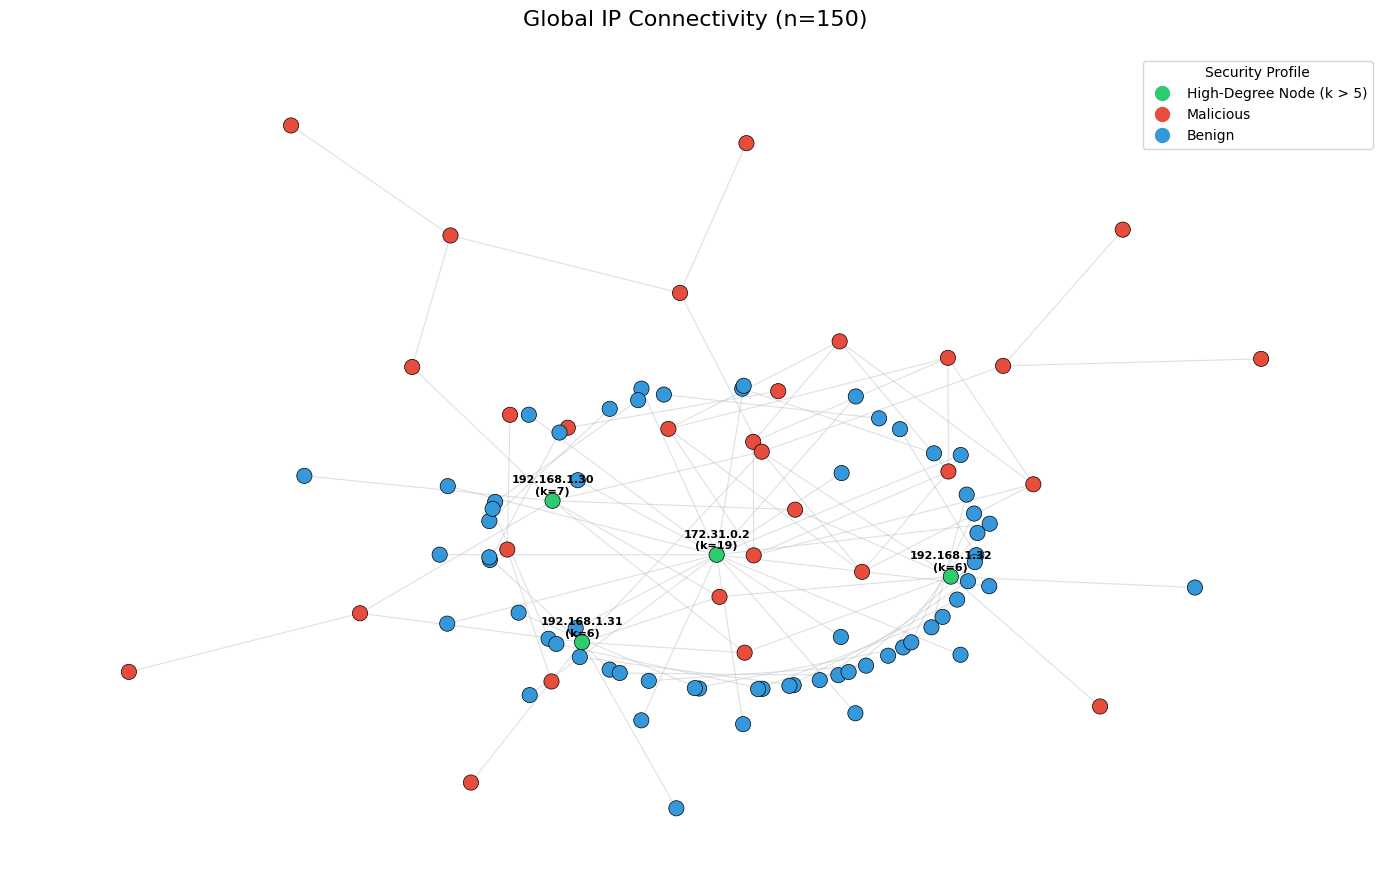

In [3]:
# Visualize the original dataset graph
eCN.vis_original_overall_graph(df)

Verified Topology: Star (Diam=2)


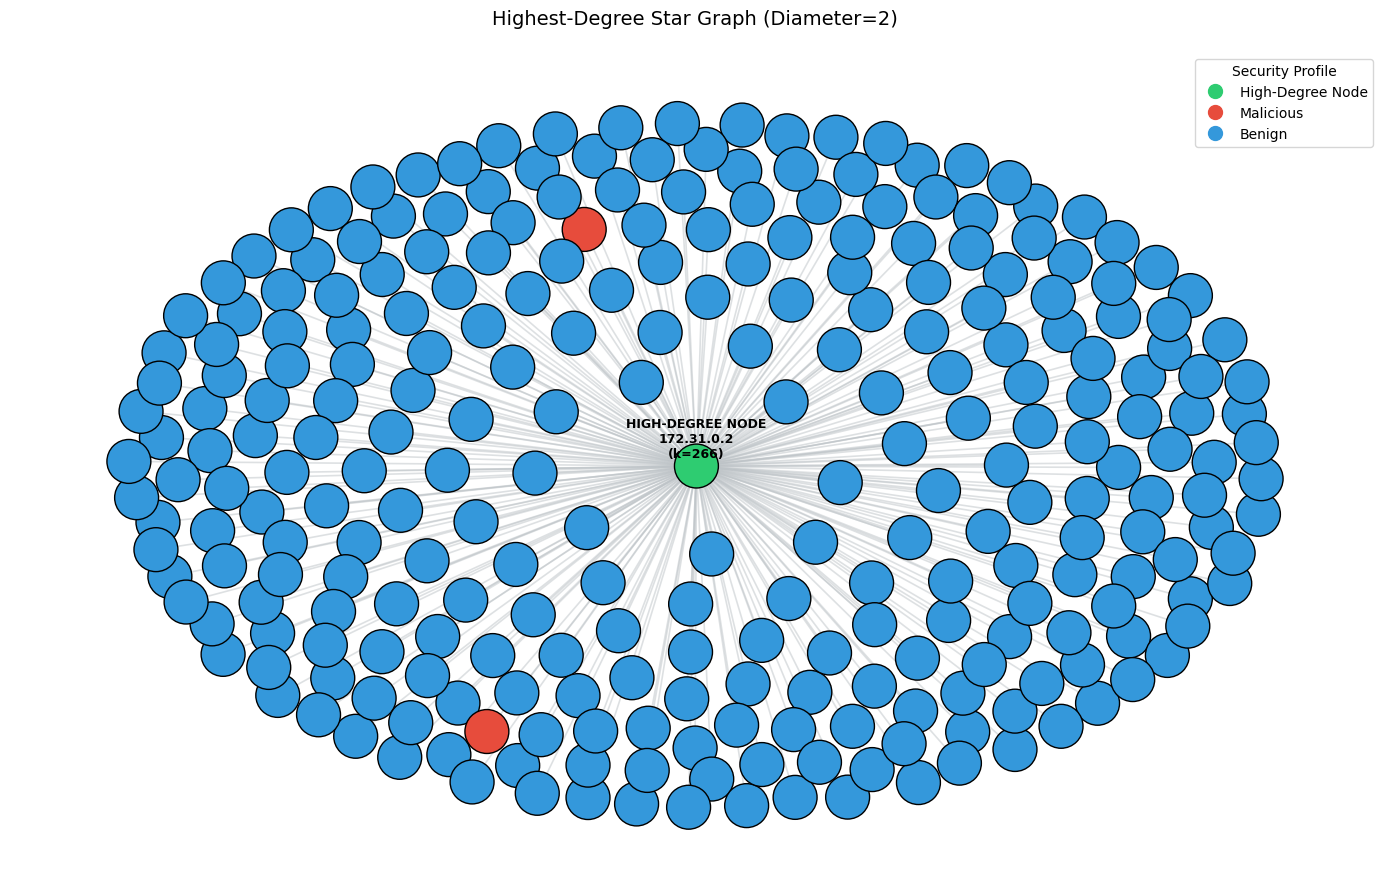

In [4]:
# Visualize the highest-degree star graph
eCN.vis_original_star_graph(df)

========== START GRAPH GENERATION COMPARISON ==========


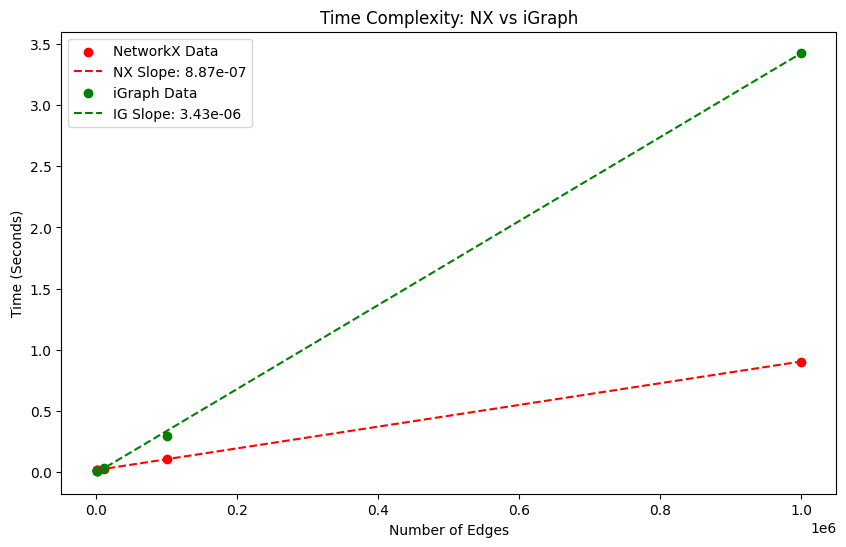

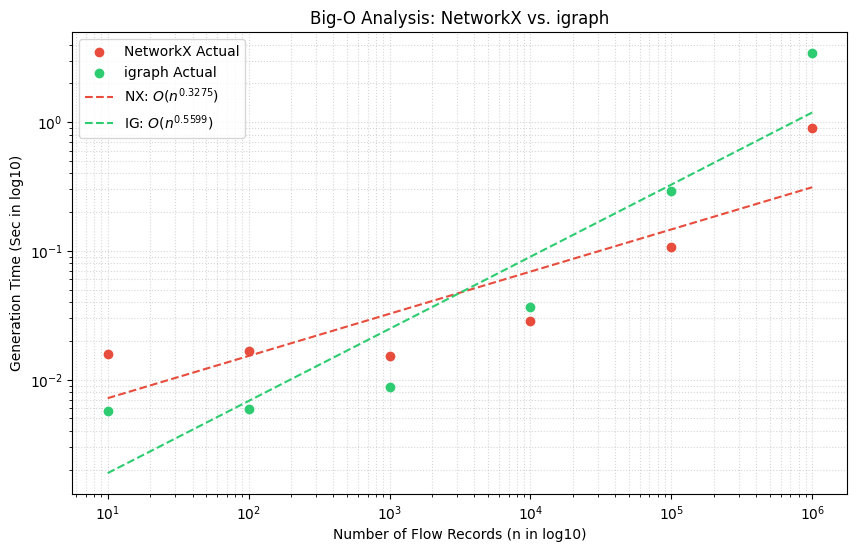

========== START ADJACENCY MATRIX GENERATION COMPARISON ==========


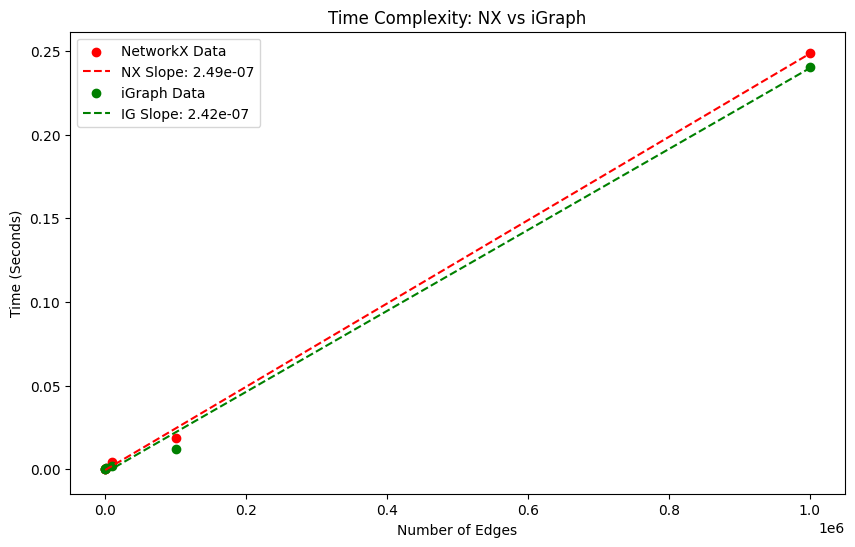

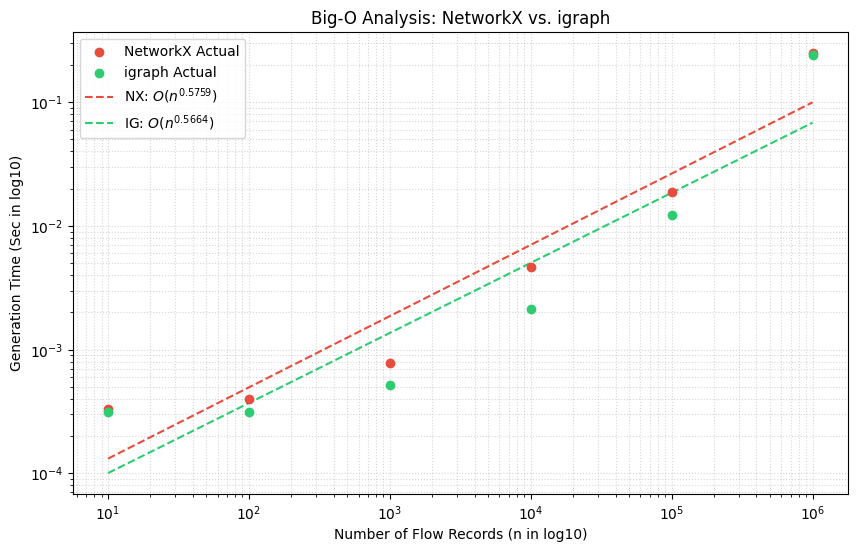

========== START MATRIX MULTIPLICATION GENERATION COMPARISON ==========


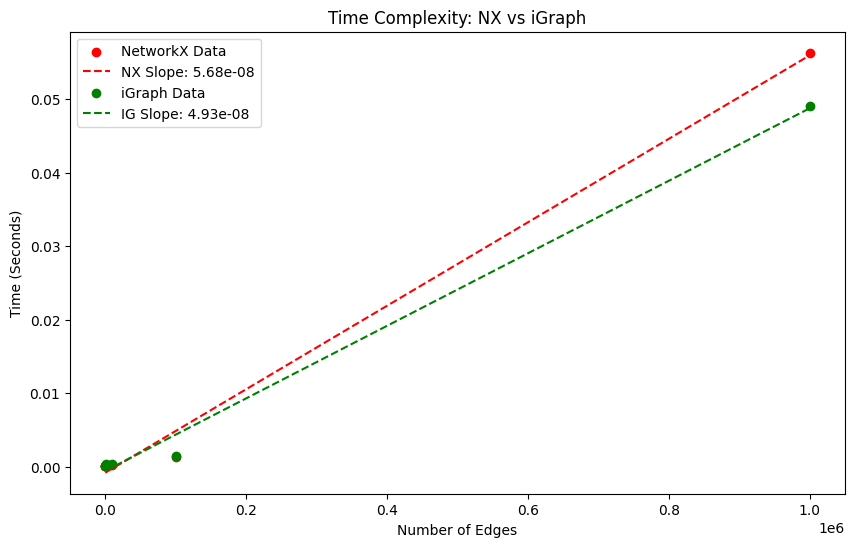

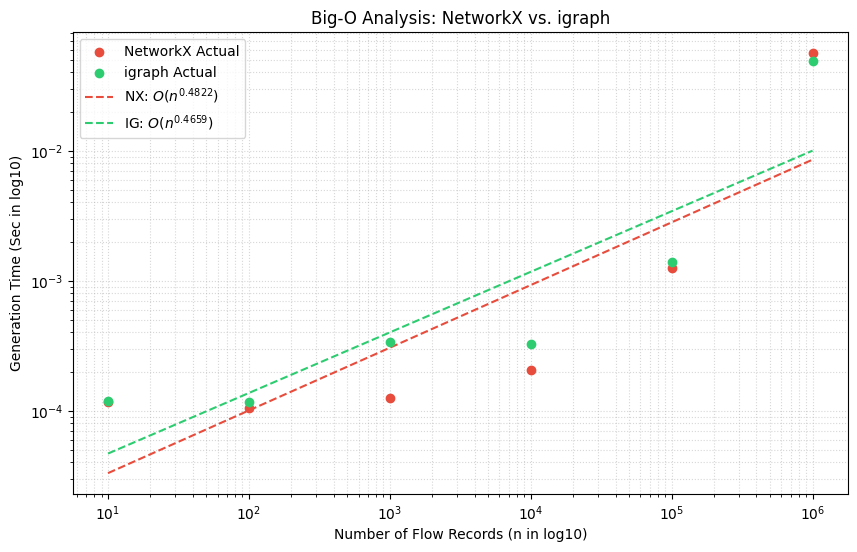

In [5]:
# Visualize graph, adjacency matrix, and matrix multiplication generation timings
eCN.batch_generate_timing(df)

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Complex Network Feature Engineering

- [Back to Table of Contents](#table-of-contents)

</div>

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Initial Data Dictionary

- [Back to Table of Contents](#table-of-contents)

</div>

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Statistical and Associative Data Exploration

- [Back to Table of Contents](#table-of-contents)

</div>

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Final Data Dictionary

- [Back to Table of Contents](#table-of-contents)

</div>